<a href="https://colab.research.google.com/github/Avnish-Bhakhar/AI-Essential/blob/main/CSE428.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
#Training Dataa
X = np.array([[1],[2],[3],[4]]);
Y= np.array([10,20,30,40]);
model = LinearRegression()
model.fit(X,Y)
x= int(input("Enter Number of hours: "))
print(model.predict([[x]]))


Enter Number of hours: 30
[300.]


In [ ]:
#Simple if else
x= float(input("Temperature: "))
if (x>30):
  print("Hot -> Turn ON fan")
elif (x>20):
  print("Normal -> Turn on FAN speed slow ")
else:
  print("Cold --> Turn off FAN")

Temperature: 567
Hot -> Turn ON fan


In [ ]:
#In a factory people are working in a manufacturing factory where they are manufacturing some products such as pipes for two hours working they get 160 rupees for 4 hours 320
# for 8 hours 640 perform linear regression
from sklearn.linear_model import LinearRegression
import numpy as np
#Training Dataa
X = np.array([[2],[4],[6],[8]]);
Y= np.array([160,320,480,640]);
model = LinearRegression()
model.fit(X,Y)
x= int(input("Enter Number of working Hours : "))
print("Total wages: ",model.predict([[x]]),"Rupees")

Enter Number of working Hours : 5
Total wages:  [400.] Rupees


In [ ]:
from collections import deque

# Jug capacities
Cap_a = 4
Cap_b = 3

# Goal state
G = (2, 0)

def get_next_state(state):
    a, b = state
    states = []

    # Fill jug A
    states.append((Cap_a, b))

    # Fill jug B
    states.append((a, Cap_b))

    # Empty jug A
    states.append((0, b))

    # Empty jug B
    states.append((a, 0))

    # Pour B -> A
    transfer = min(b, Cap_a - a)
    states.append((a + transfer, b - transfer))

    # Pour A -> B
    transfer = min(a, Cap_b - b)
    states.append((a - transfer, b + transfer))

    return states


def bfs_water_jug():
    start = (0, 0)
    queue = deque([(start, [start])])
    visited = set()

    while queue:
        current_state, path = queue.popleft()

        if current_state in visited:
            continue

        visited.add(current_state)

        if current_state == G:
            return path

        for next_state in get_next_state(current_state):
            if next_state not in visited:
                queue.append((next_state, path + [next_state]))

    return None


# Run BFS
sol = bfs_water_jug()

if sol:
    print("Solution path (JUG A, JUG B):")
    for step in sol:
        print(step)
else:
    print("No solution found")


Solution path (JUG A, JUG B):
(0, 0)
(0, 3)
(3, 0)
(3, 3)
(4, 2)
(0, 2)
(2, 0)


In [ ]:
from collections import deque

# GOAL state
goal = (1, 2, 3,
        4, 5, 6,
        7, 8, 0)

# Possible moves (index shift)
MOVES = {
    'UP': -3,
    'DOWN': 3,
    'LEFT': -1,
    'RIGHT': 1
}

def is_valid_move(zero_pos, move):
    if move == 'LEFT' and zero_pos % 3 == 0:
        return False
    if move == 'RIGHT' and zero_pos % 3 == 2:
        return False
    if move == 'UP' and zero_pos < 3:
        return False
    if move == 'DOWN' and zero_pos > 5:
        return False
    return True


def get_next_states(state):
    zero_pos = state.index(0)
    next_states = []

    for move, shift in MOVES.items():
        if is_valid_move(zero_pos, move):
            new_pos = zero_pos + shift
            new_state = list(state)

            # swap blank (0) with target tile
            new_state[zero_pos], new_state[new_pos] = \
                new_state[new_pos], new_state[zero_pos]

            next_states.append(tuple(new_state))

    return next_states


def bfs_8_puzzle(start):
    queue = deque([(start, [start])])
    visited = set()

    while queue:
        current_state, path = queue.popleft()

        if current_state in visited:
            continue

        visited.add(current_state)

        if current_state == goal:
            return path

        for next_state in get_next_states(current_state):
            if next_state not in visited:
                queue.append((next_state, path + [next_state]))

    return None



start_state = (1, 2, 3,4, 0, 6,7, 5, 8)

solution = bfs_8_puzzle(start_state)

if solution:
    print("Solution path:")
    for step in solution:
        print(step[0:3])
        print(step[3:6])
        print(step[6:9])
        print("-----")
else:
    print("No solution found")


Solution path:
(1, 2, 3)
(4, 0, 6)
(7, 5, 8)
-----
(1, 2, 3)
(4, 5, 6)
(7, 0, 8)
-----
(1, 2, 3)
(4, 5, 6)
(7, 8, 0)
-----


In [ ]:
import tensorflow as tf

#simple tensors

a = tf.constant(10)
b = tf.constant(5)

print("Addition: ",(a+b).numpy())
print("Subtraction: ",(a-b).numpy())
print("Multiplication: ",(a*b).numpy())
print("Division: ",(a/b).numpy())

Addition:  15
Subtraction:  5
Multiplication:  50
Division:  2.0


In [ ]:
from collections import deque

# GOAL state
goal = (2, 8, 1,
        'a', 4, 3,
        7, 6, 5)

# Possible moves (index shift)
MOVES = {
    'UP': -3,
    'DOWN': 3,
    'LEFT': -1,
    'RIGHT': 1
}

def is_valid_move(blank_pos, move):
    if move == 'LEFT' and blank_pos % 3 == 0:
        return False
    if move == 'RIGHT' and blank_pos % 3 == 2:
        return False
    if move == 'UP' and blank_pos < 3:
        return False
    if move == 'DOWN' and blank_pos > 5:
        return False
    return True


def get_next_states(state):
    blank_pos = state.index('a')
    next_states = []

    for move, shift in MOVES.items():
        if is_valid_move(blank_pos, move):
            new_pos = blank_pos + shift
            new_state = list(state)

            # swap blank ('a') with target tile
            new_state[blank_pos], new_state[new_pos] = \
                new_state[new_pos], new_state[blank_pos]

            next_states.append(tuple(new_state))

    return next_states


def bfs_8_puzzle(start):
    queue = deque([(start, [start])])
    visited = set()

    while queue:
        current_state, path = queue.popleft()

        if current_state in visited:
            continue

        visited.add(current_state)

        if current_state == goal:
            return path

        for next_state in get_next_states(current_state):
            if next_state not in visited:
                queue.append((next_state, path + [next_state]))

    return None


# INITIAL state
start_state = (1, 2, 3,
               8, 'a', 4,
               7, 6, 5)

solution = bfs_8_puzzle(start_state)

if solution:
    print("Solution path:")
    for step in solution:
        print(step[0:3])
        print(step[3:6])
        print(step[6:9])
        print("-----")
else:
    print("No solution found")


Solution path:
(1, 2, 3)
(8, 'a', 4)
(7, 6, 5)
-----
(1, 'a', 3)
(8, 2, 4)
(7, 6, 5)
-----
('a', 1, 3)
(8, 2, 4)
(7, 6, 5)
-----
(8, 1, 3)
('a', 2, 4)
(7, 6, 5)
-----
(8, 1, 3)
(2, 'a', 4)
(7, 6, 5)
-----
(8, 1, 3)
(2, 4, 'a')
(7, 6, 5)
-----
(8, 1, 'a')
(2, 4, 3)
(7, 6, 5)
-----
(8, 'a', 1)
(2, 4, 3)
(7, 6, 5)
-----
('a', 8, 1)
(2, 4, 3)
(7, 6, 5)
-----
(2, 8, 1)
('a', 4, 3)
(7, 6, 5)
-----


In [ ]:
# implention of CSP -- Constrain satisfaction problem
def sovle_n_queens_csp(n):

    # store all solutions
    solutions = []

    # track constraints
    columns = set()
    diag1 = set()
    diag2 = set()

    board = [-1] * n   # board[row] = column index

    def backktrack(row):
        if row == n:
            solutions.append(board.copy())
            return

        for col in range(n):
            if col in columns or (row - col) in diag1 or (row + col) in diag2:
                continue  # not SAFE

            board[row] = col
            columns.add(col)
            diag1.add(row - col)
            diag2.add(row + col)

            # recurse
            backktrack(row + 1)

            # undo BACKTRACK
            board[row] = -1
            columns.remove(col)
            diag1.remove(row - col)
            diag2.remove(row + col)

    backktrack(0)
    return solutions


def print_solutions(n, solutions):
    print(f"\nTotal solutions for N = {n} is {len(solutions)}\n")

    for sol in solutions:
        for row in range(n):
            line = ""
            for col in range(n):
                if sol[row] == col:
                    line += "Q "
                else:
                    line += ". "
            print(line)
        print("-" * (2 * n))


# ===============RUN=================
#N = 8 # chnage this value for differnet board sizes
n = 8
solutions = sovle_n_queens_csp(n)
print_solutions(n, solutions)



Total solutions for N = 8 is 92

Q . . . . . . . 
. . . . Q . . . 
. . . . . . . Q 
. . . . . Q . . 
. . Q . . . . . 
. . . . . . Q . 
. Q . . . . . . 
. . . Q . . . . 
----------------
Q . . . . . . . 
. . . . . Q . . 
. . . . . . . Q 
. . Q . . . . . 
. . . . . . Q . 
. . . Q . . . . 
. Q . . . . . . 
. . . . Q . . . 
----------------
Q . . . . . . . 
. . . . . . Q . 
. . . Q . . . . 
. . . . . Q . . 
. . . . . . . Q 
. Q . . . . . . 
. . . . Q . . . 
. . Q . . . . . 
----------------
Q . . . . . . . 
. . . . . . Q . 
. . . . Q . . . 
. . . . . . . Q 
. Q . . . . . . 
. . . Q . . . . 
. . . . . Q . . 
. . Q . . . . . 
----------------
. Q . . . . . . 
. . . Q . . . . 
. . . . . Q . . 
. . . . . . . Q 
. . Q . . . . . 
Q . . . . . . . 
. . . . . . Q . 
. . . . Q . . . 
----------------
. Q . . . . . . 
. . . . Q . . . 
. . . . . . Q . 
Q . . . . . . . 
. . Q . . . . . 
. . . . . . . Q 
. . . . . Q . . 
. . . Q . . . . 
----------------
. Q . . . . . . 
. . . . Q . . . 
. . . . . . Q 

Total Tosses: 1000
Total Heads: 510
Total Tails: 490
Probability of Head: 0.51


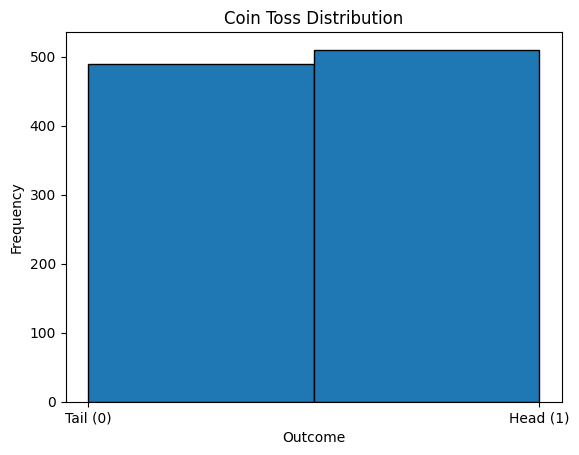

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# simulate 1000 coin tosses
np.random.seed(42)
coin_toss = np.random.choice([0, 1], size=1000)  # 0 = tail , 1 = head


# probability of getting head
total_heads = np.sum(coin_toss)
probability_head = total_heads / len(coin_toss)

print("Total Tosses:", len(coin_toss))
print("Total Heads:", total_heads)
print("Total Tails:", len(coin_toss) - total_heads)
print("Probability of Head:", probability_head)


# plot histogram
plt.hist(coin_toss, bins=2, edgecolor='black')
plt.xticks([0, 1], ['Tail (0)', 'Head (1)'])
plt.xlabel("Outcome")
plt.ylabel("Frequency")
plt.title("Coin Toss Distribution")
plt.show()


In [ ]:
import numpy as np

data = np.random.randint(1,100,20)

print("Data: ",data)
print("Mean: ",np.mean(data))
print("Median: ",np.var(data))
print("variance")
print("standard deviation")

Predicted Prices: [487142.85714286 207142.85714286]
Actual Prices: [480000 200000]
Mean Squared Error: 51020408.16326575
Coefficient (Slope): 199.99999999999997
Intercept: 47142.85714285722
Predicted price for 1600 sq ft house: 367142.85714285716


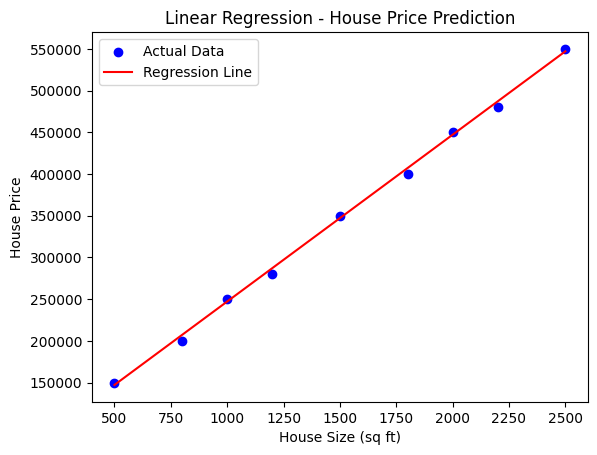

In [ ]:
# supervised machine learning example
# linear regression using scikit - learn

# 1. import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# 2. Create sample dataset (house Size vs price)
# X = feature (house size in sq ft)
# Y = target price

X = np.array([500, 800, 1000, 1200, 1500, 1800, 2000, 2200, 2500]).reshape(-1, 1)
Y = np.array([150000, 200000, 250000, 280000, 350000, 400000, 450000, 480000, 550000])


# 3. split into training and Testing data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


# 4. create model
model = LinearRegression()


# 5. train model
model.fit(X_train, Y_train)


# 6. Make prediction
Y_pred = model.predict(X_test)

print("Predicted Prices:", Y_pred)
print("Actual Prices:", Y_test)


# Evaluate Model
mse = mean_squared_error(Y_test, Y_pred)
print("Mean Squared Error:", mse)

print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)


# Predict price for new house (example: 1600 sq ft)
new_size = np.array([[1600]])
predicted_price = model.predict(new_size)
print("Predicted price for 1600 sq ft house:", predicted_price[0])


# Vplot results
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')

plt.xlabel("House Size (sq ft)")
plt.ylabel("House Price")
plt.title("Linear Regression - House Price Prediction")
plt.legend()
plt.show()


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = np.array([
    [2, 5],
    [3, 6],
    [5, 8],
    [7, 7],
    [8, 6],
    [1, 4],
    [6, 9],
    [9, 5]
])

y = np.array([0, 0, 0, 1, 1, 1, 0, 1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Accuracy
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# 🔥 NEW PREDICTION
new_point = np.array([[4, 7]])
prediction = knn.predict(new_point)

print("Prediction for [4, 7]:", prediction)

Accuracy: 0.5
Prediction for [4, 7]: [0]


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target # Target labels

print("Iris dataset loaded successfully.")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Target classes: {iris.target_names}")



Iris dataset loaded successfully.
Number of samples: 150
Number of features: 4
Target classes: ['setosa' 'versicolor' 'virginica']


Next, we will split the dataset into training and testing sets. This is crucial for evaluating the model's performance on unseen data.

In [ ]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 105 samples
Testing set size: 45 samples


Now, we will initialize and train a KNeighborsClassifier. We'll use `n_neighbors=3` for this example, meaning it will consider the 3 nearest neighbors for classification.

In [ ]:
# 3. Initialize and train a KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

print("KNeighborsClassifier trained successfully.")

KNeighborsClassifier trained successfully.


Finally, we will make predictions on the test set and evaluate the model's accuracy.

In [ ]:
# 4. Make predictions on the test set
y_pred = knn.predict(X_test)

# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Model predictions on test set: {y_pred}")
print(f"Actual labels for test set:   {y_test}")
print(f"Accuracy of the KNeighborsClassifier: {accuracy:.2f}")

Model predictions on test set: [2 1 1 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 1 2 1]
Actual labels for test set:   [2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 2 2 1]
Accuracy of the KNeighborsClassifier: 0.96


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

### Create Sample Data for Hours Studied vs. Pass/Fail
Let's create a synthetic dataset where 'Hours Studied' is the feature (X) and 'Pass/Fail' is the target (y). We'll assume a threshold where more hours generally lead to passing.

In [ ]:
# Generate synthetic data
np.random.seed(42)
hours_studied = np.random.rand(100, 1) * 10 # Hours from 0 to 10

# Simple rule: if hours_studied > 5, then pass (1), otherwise fail (0)
# Add some noise to make it more realistic
pass_fail = (hours_studied + np.random.randn(100, 1) * 2 > 5).astype(int)

X = hours_studied
y = pass_fail.flatten()

print("First 5 samples of Hours Studied:\n", X[:5])
print("First 5 samples of Pass/Fail:\n", y[:5])

First 5 samples of Hours Studied:
 [[3.74540119]
 [9.50714306]
 [7.31993942]
 [5.98658484]
 [1.5601864 ]]
First 5 samples of Pass/Fail:
 [0 1 1 0 0]


### Split Data into Training and Testing Sets
We'll split the dataset to train the model on a portion of the data and test its performance on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 70 samples
Testing set size: 30 samples


### Train the RandomForestClassifier
Now, let's initialize and train a `RandomForestClassifier`. We can specify parameters like `n_estimators` (number of trees in the forest).

In [ ]:
# Initialize the Random Forest Classifier
# n_estimators is the number of trees in the forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("RandomForestClassifier trained successfully.")

RandomForestClassifier trained successfully.


### Make Predictions and Evaluate the Model
After training, we'll use the model to make predictions on the test set and evaluate its accuracy and other performance metrics.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Model predictions on test set:", y_pred)
print("Actual labels for test set:  ", y_test)
print(f"\nAccuracy of the RandomForestClassifier: {accuracy:.2f}")
print("\nClassification Report:\n", report)

Model predictions on test set: [1 0 1 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 1 1 0]
Actual labels for test set:   [0 0 1 0 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 1 1 0 0 1 1 1 0]

Accuracy of the RandomForestClassifier: 0.83

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.86        17
           1       0.83      0.77      0.80        13

    accuracy                           0.83        30
   macro avg       0.83      0.83      0.83        30
weighted avg       0.83      0.83      0.83        30



### Predict for a New Student
Let's see how the model predicts for a new student with a specific number of hours studied.

In [ ]:
# Example prediction for a new student
new_hours_studied = np.array([[6.5]]) # Student studied 6.5 hours
prediction = model.predict(new_hours_studied)

if prediction[0] == 1:
    print(f"A student studying {new_hours_studied[0][0]} hours is predicted to: Pass")
else:
    print(f"A student studying {new_hours_studied[0][0]} hours is predicted to: Fail")

A student studying 6.5 hours is predicted to: Fail


Linear Algebra


In [2]:
import numpy as np

print("----------Dot Product ----------------")
x = np.array([2,3])
y = np.array([4,5])

dot_product = np.dot(x,y)
print(dot_product)

print("----------Cross Product ----------------")
cross_product = np.cross(x,y)
print(cross_product)


print("---------- Matrix addition--------------")
matrix1 = np.array([[1,3],
                    [2,4]])
matrix2 = np.array([[5,6],
                    [7,8]])
print("A+b = \n", matrix1 + matrix2)


print("---------- Matrix multiplication--------------")
matrix = np.array([[1,2],
                  [3,4]])
matrix2 = np.array([[5,6],
                    [7,8]])
print("A+b = \n",np.matmul(matrix,matrix2))

print("---------- Matrix Transpose--------------")

A = np.array([[1,2],
           [3,4]])

print("Transpose of A = \n",A.T)


print("---------- Matrix Determinant--------------")

A = np.array([[1,2],
           [3,4]])

print("Determinant of A = \n",np.linalg.det(A))


print("---------- Matrix Inverse--------------")

A = np.array([[1,2],
           [3,4]])

print("Inverse of A = \n",np.linalg.inv(A))




print("---------- Solve Linear  Equation--------------")
#2x + y =5
#x+y = 3
A = np.array([[2,1],
           [1,1]])
B = np.array([5,3])
solution = np.linalg.solve(A,B)
print("Solution = \n",solution)




----------Dot Product ----------------
23
----------Cross Product ----------------
-2
---------- Matrix addition--------------
A+b = 
 [[ 6  9]
 [ 9 12]]
---------- Matrix multiplication--------------
A+b = 
 [[19 22]
 [43 50]]
---------- Matrix Transpose--------------
Transpose of A = 
 [[1 3]
 [2 4]]
---------- Matrix Determinant--------------
Determinant of A = 
 -2.0000000000000004
---------- Matrix Inverse--------------
Inverse of A = 
 [[-2.   1. ]
 [ 1.5 -0.5]]
---------- Solve Linear  Equation--------------
Solution = 
 [2. 1.]


/tmp/ipython-input-443/2299970260.py:11: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  cross_product = np.cross(x,y)


**Ai** **Prediction**


In [5]:
print("--------------Ai Prediction---------------")
x = np.array([3,2])
w = np.array([5,4])

b = 1

prediction = np.dot(x,w) + b
print(prediction)
#

--------------Ai Prediction---------------
24


**For 3X3 matrix**

In [7]:
A = np.array([[1,2,3],
             [4,5,6],
             [7,8,9]])

B = np.array([[4,5,6],
              [1,2,3],
              [9,8,7]])
print("-----------Dot pproduct -----------------")
print(np.dot(A,B))


print("-----------Cross pproduct -----------------")
print(np.cross(A,B))

print("-----------Transpose -----------------")
print(A.T)

print("-----------Inverse -----------------")
# For inverse and determinant, let's use a non-singular matrix
A_invertible = np.array([[1,2,0],
                       [0,1,0],
                       [0,0,1]])
print("Original matrix for inverse:\n", A_invertible)
print("Inverse of A_invertible = \n",np.linalg.inv(A_invertible))

print("-----------Determinant -----------------")
print("Determinant of A_invertible = \n",np.linalg.det(A_invertible))


print("-------------prediction----------------")
b = 1

prediction = np.dot(A,B) + b
print(prediction)

-----------Dot pproduct -----------------
[[ 33  33  33]
 [ 75  78  81]
 [117 123 129]]
-----------Cross pproduct -----------------
[[ -3   6  -3]
 [  3  -6   3]
 [-16  32 -16]]
-----------Transpose -----------------
[[1 4 7]
 [2 5 8]
 [3 6 9]]
-----------Inverse -----------------
Original matrix for inverse:
 [[1 2 0]
 [0 1 0]
 [0 0 1]]
Inverse of A_invertible = 
 [[ 1. -2.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]
-----------Determinant -----------------
Determinant of A_invertible = 
 1.0
-------------prediction----------------
[[ 34  34  34]
 [ 76  79  82]
 [118 124 130]]


### Linear Algebra Operations for 3x3 Matrices

This section demonstrates various linear algebra operations using 3x3 NumPy arrays (matrices), including dot product, cross product, transpose, inverse, determinant, and AI prediction (vector-matrix operation).



In [ ]:
A = np.array([[1,2,3],
             [4,5,6],
             [7,8,9]])

B = np.array([[4,5,6],
              [1,2,3],
              [9,8,7]])
print("-----------Dot pproduct -----------------")
print(np.dot(A,B))

### Dot Product (Matrix Multiplication)

The dot product, when applied to two matrices, performs matrix multiplication. This operation involves multiplying rows by columns and summing the results to form the elements of the new matrix. The result is a 3x3 matrix from the multiplication of two 3x3 matrices.

In [ ]:
print("-----------Cross pproduct -----------------")
print(np.cross(A,B))

### Cross Product

The `np.cross()` function in NumPy calculates the cross product of two 1-D arrays or the cross product of corresponding rows or columns of 2-D arrays. For 3x3 matrices, it computes the cross product row-wise or column-wise depending on the axis parameter (default is the last axis).

In [ ]:
print("-----------Transpose -----------------")
print(A.T)

### Matrix Transpose

Transposing a matrix means swapping its rows and columns. If the original matrix is `A`, its transpose `A.T` will have `A[i][j]` at position `A.T[j][i]`.

In [ ]:
print("-----------Inverse -----------------")
# For inverse and determinant, let's use a non-singular matrix
A_invertible = np.array([[1,2,0],
                       [0,1,0],
                       [0,0,1]])
print("Original matrix for inverse:\n", A_invertible)
print("Inverse of A_invertible = \n",np.linalg.inv(A_invertible))

### Matrix Inverse

 The inverse of a square matrix `A`, denoted `A^-1`, is a matrix such that when multiplied by `A`, it yields the identity matrix. Not all matrices have an inverse; only non-singular matrices (those with a non-zero determinant) are invertible. Here, we use `A_invertible` to demonstrate the inverse.

In [ ]:
print("-----------Determinant -----------------")
print("Determinant of A_invertible = \n",np.linalg.det(A_invertible))

### Matrix Determinant

The determinant is a scalar value that can be computed from the elements of a square matrix. It provides important information about the matrix, such as whether it is invertible (non-zero determinant implies invertibility). Here, we calculate the determinant of `A_invertible`.

In [ ]:
print("-------------prediction----------------")
b = 1

prediction = np.dot(A,B) + b
print(prediction)

### AI Prediction (Simple Linear Model)

This demonstrates a very simplified form of an 'AI prediction' using matrix operations, akin to a linear model where `prediction = (input_matrix \* weight_matrix) + bias`. Here, `A` is treated as input, `B` as weights, and `b` as a bias term. The dot product combines `A` and `B`, and then the scalar bias `b` is added to every element of the resulting matrix.